In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/content/matches.csv')
df

FileNotFoundError: [Errno 2] No such file or directory: '/content/matches.csv'

In [ ]:
#take an overview(preview) of the data
df.head()  #it will show the first 5 rows
df.head(2) #it will show the first 2 rows
df.tail()  #it will show the last 5 rows
df.tail(2) #it will show the last 2 rows

In [ ]:
#shape of the data
df.shape #it tell us about the no of rows and column in the data
df.shape[0] #no of rows
df.shape[1] #no of column

In [ ]:
#preview the information of the given data
df.info()

In [ ]:
#describe
df.describe() #it works only on numerical column

In [ ]:
#Access one column by name in a series(index + values)
df['winner']
type(df['winner']) #series
df['winner'].shape

#Access multiple columns
df[['team1','team2','winner']]
type(df[['team1','team2','winner']]) #dataframe

In [ ]:
#slicing and indexing
df[df['win_by_runs'] > 20]
mask = df["win_by_runs"] > 20
df[mask]

In [ ]:
# df.iloc[row_positions, column_positions]
df.iloc[1]  #Select a row by position
df.iloc[0:3]   #Select rows using slicing
df.iloc[1, 2]  #Select specific cells
df.iloc[[0, 2], [0, 2]]  #Select multiple rows & columns


# 1. Select a single row
df.iloc[2]


# 2. Select multiple rows (list of indices)
df.iloc[[0, 2, 4]]


# 3. Row slicing (start:stop:step)
df.iloc[1:4]          # rows 1,2,3
df.iloc[0:5:2]        # rows 0,2,4

# 4. Select a single column
df.iloc[:, 1]


# 5. Select multiple columns
df.iloc[:, [0, 2]]


# 6. Column slicing
df.iloc[:, 1:4]


# 7. Select specific rows and columns
df.iloc[1:4, 0:3]


# 8. Select individual cell (scalar)
df.iloc[3, 2]


# 9. Mixed slicing (list + slice)
df.iloc[[0, 3], 1:3]


# 10. Reverse rows
df.iloc[::-1]


# 11. Reverse columns
df.iloc[:, ::-1]


# 12. Step slicing (skip rows & columns)
df.iloc[::2, ::2]

# 13. Last row
df.iloc[-1]


# 14. Last column
df.iloc[:, -1]


# 15. Sub-matrix extraction
df.iloc[1:4, [0, 2, 3]]

#filtering data frame on a condition

In [ ]:
mask = df["city"] == 'Hyderabad'  #boolean series
df[mask]  #dataframe that contains mathches in hyderabad
df[mask].shape[0]

In [ ]:
def get_city_match_count(city):
  mask = df["city"] == city
  return df[mask].shape[0]

get_city_match_count('Rajkot')

In [ ]:
#filtering the matches that played in hyderabad after 2010
mask1 = df['city'] == 'Hyderabad'
mask2 = df['date'] > '2010-01-01'
df[mask & mask2].shape[0]   #& is bitwise operator because mask1 and mask2 are boolean series

# Value counts

In [ ]:
 #Kis team ne sabse jyda matches jeete
winner_of_all_time = df["winner"].value_counts()
winner_of_all_time[0]

In [ ]:
#plot the data
import matplotlib.pyplot as plt
df["winner"].value_counts().head().plot(kind="barh")

In [ ]:
df['toss_decision'].value_counts().plot(kind='pie')

In [ ]:
df["win_by_runs"].plot(kind='hist')

In [ ]:
#Series in pandas
#there are two things in series 1. index and 2. values
myseries = df['winner'].value_counts()
myseries.index  #give the all indexs
myseries.values # give the all values of the indexes
myseries.head()
myseries.tail()
myseries['Mumbai Indians']  #it returns the values of the index


In [ ]:
#kis team ne sabse jyada match khele hai as  team 1 + as team 2
match_played = df['team1'].value_counts() + df['team2'].value_counts()
match_played

In [ ]:
# Find the team with most matches
match_played.idxmax()   # team name
match_played.max()      # number of matches


# sort values

Accending and decending

In [ ]:
match_played = df['team1'].value_counts() + df['team2'].value_counts()
match_played.sort_values(ascending=False)

In [ ]:
#sort the cities in the order
df.sort_values(by='city')
df.sort_values('city', ascending=False)
df.sort_values(['city', 'date'])
df.sort_values(['city', 'date'], ascending=[True, False])

# inplace=True changes in the orginal data so use it carefully
# df.sort_values('city', ascending=False, inplace=True)

# Drop Duplicate()

In [ ]:
df.drop_duplicates(subset='city')  # we can add inplace=True
df.drop_duplicates(subset=['city', 'season']).shape
df.drop_duplicates(subset=['winner', 'season'])

In [ ]:
#drop duplicate is very tricky to use .

#suppose we want to find har season main konsi team final jiti hai......to uske liye hame season ka ek match select krna hai ... vo match last match hoga to final match h jisme kisi ek ne jeeta hai

df.sort_values('season').drop_duplicates(subset='season', keep='last')

# Access the season and the winner
df.sort_values('season').drop_duplicates(subset='season', keep='last')[['season', 'winner']]

# Second  Data Set of Companies

# Groupby() method


In [ ]:
# data = pd.read_csv('/content/Fortune.csv',  encoding='latin1')

# len(sectors)    #it makes the group of sectors
# sectors.size()  #it will return how many companies are in each sectors
# sectors.size().sort_values(ascending=False) #it will give sabse jyada companies kis sector me hai

# sectors.first() #it will give us the first company name in each sector
# #similarly
# sectors.last()
# sectors.groups #returns the dictionary with the company and its index
# company.iloc[23, :]  #veryfied

# sectors.get_group('Energy') # it will show the all companies of energy sector
# sectors.sum() # it will sum all the column values of the each sector
# sector['revenues'].mean().sort_values(ascending=False)
# sector['profits'].max()
# sector['profits'].min()
# sector.max()
# sector.min()
# sector.describe()

# Groupby() method on match data

In [ ]:
delivery = pd.read_csv('/content/deliveries.csv')
delivery.head()

In [ ]:
delivery.head(2)
delivery.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head()  #sabse jyda runs

In [ ]:
#IPL me sabse jyada 6 marne wale batsman
mask = delivery['batsman_runs'] == 6
delivery[mask].groupby('batsman') ['batsman_runs'].count().sort_values(ascending=False).head()

In [ ]:
#Kis team ke against Virat Kohli ne sabse adhik run banaye
mask = delivery['batsman'] == 'V Kohli'
delivery[mask].groupby('bowling_team')['batsman_runs'].sum().sort_values(ascending=False).head(10)

def heighest_runs_by_batsman(batsman_name):
  mask = delivery['batsman'] == batsman_name
  return delivery[mask].groupby('bowling_team')['batsman_runs'].sum().sort_values(ascending=False).head(1)
heighest_runs_by_batsman('MS Dhoni')

# isin()

In [ ]:
# Death overs(16-20) me sabse jyada khatarnaak khiladi kon h on the basis of strike rate and jisne minimum 200 balls kheli hai

#strike rate = (no of runs / no of balls) * 100

#first we will filter the death over
death_over = delivery[delivery['over'] > 15]
all_batsman = delivery.groupby('batsman')['batsman_runs'].count()
x = all_batsman > 200
batsman_list = all_batsman[x].index.tolist() # tolist() convert it into list

#run scored by all these batsman
#Balls played by these batsman

final = death_over[death_over['batsman'].isin(batsman_list)] #isin() me parameter me list leta h

runs = final.groupby('batsman')['batsman_runs'].sum()
balls = final.groupby('batsman')['batsman_runs'].count()

sr = (runs/balls)*100
sr.sort_values(ascending=False).head(10)

# Merge

In [ ]:
# Merge
new = delivery.merge(df, left_on='match_id', right_on='id').shape
print(delivery.shape)
print(df.shape)

In [ ]:
# new.groupby(['season', 'batsman'])['batsman_runs'].sum().sort_values(ascending=False)    # ----> type of this series will have 2 indeces

# new.groupby(['season', 'batsman'])['batsman_runs'].sum().sort_values(ascending=False).reset_index().drop_duplicates(subset = 'season', keep='first').sort_values('season')['season', 'batsman']   # reset_index() converts series to dataframe

# Pandas Pivot Table

In [ ]:
# food = pd.read_csv('food.csv')
# food.shape
# # food.head()

In [ ]:
# food.pivot_table(index=['city', 'gender'], columns=['item', 'Frequency'], values='spends', aggfunc='mean')

# Applying Pivot table to IPL Dataset

In [3]:
import numpy as np
import pandas as pd

In [5]:
match = pd.read_csv('/content/matches.csv')
delivery = pd.read_csv('/content/deliveries.csv')


In [7]:
mask = delivery['batsman_runs'] ==6
six = delivery[mask]
six.shape[0]

6523

In [ ]:
#we are trying to find that kis team ne kis over me sabse jyad 6 mare hai
pt = six.pivot_table(index='over', columns='batting_team', values='batsman_runs', aggfunc='count')
pt

In [ ]:
import seaborn as sns
sns.heatmap(pt)

# The Corr function

it works only on the numerical data


In [21]:
match.corr(numeric_only=True)
match.select_dtypes(include="number").corr()   # both are same

,id,season,dl_applied,win_by_runs,win_by_wickets,umpire3
id,1.000000,0.471087,0.024281,-0.010263,-0.015510,NaN
season,0.471087,1.000000,0.004170,-0.016815,-0.000708,NaN
dl_applied,0.024281,0.004170,1.000000,-0.010893,-0.011640,NaN
win_by_runs,-0.010263,-0.016815,-0.010893,1.000000,-0.565181,NaN
win_by_wickets,-0.015510,-0.000708,-0.011640,-0.565181,1.000000,NaN
umpire3,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

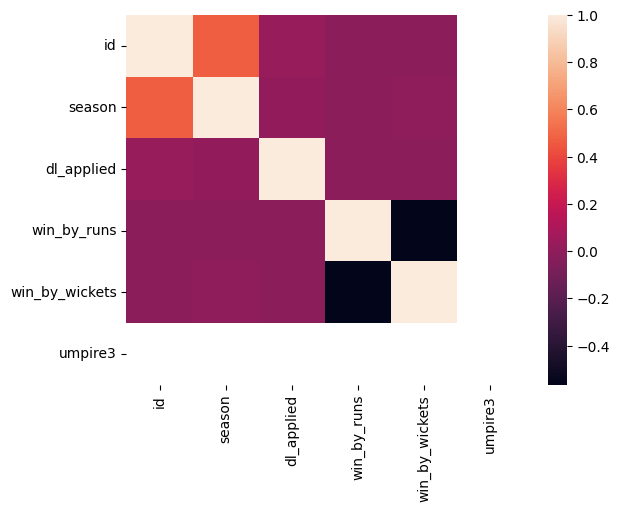

In [28]:
sns.heatmap(match.corr(numeric_only=True))

# Rename Function


In [29]:
#Rename Cols
match.rename(columns={'city': 'place', 'date': 'DOM'}, inplace=True).head()

AttributeError: 'NoneType' object has no attribute 'head'

# Set index() and reset_index()

In [30]:
# pandas automaticaly index generate krta hai ... instead of this we can use our column(like s.no.) as index

df.set_index('id', inplace=True)
df

NameError: name 'df' is not defined

In [24]:

df.reset_index(inplace=True)
df

NameError: name 'df' is not defined

In [23]:
# it converts a series into data frame
df['winner'].value_counts().reset_index()
df

# this is most important

NameError: name 'df' is not defined

# The dropna() method

Handling Missing Values


In [32]:
data = pd.read_csv('/content/train.csv',  encoding='latin1')
data.head()

(891, 12)

1. Droping missing data using dropna()

In [ ]:
data.shape

In [ ]:
data.dropna().shape   # by default it deletes the rows in that row ke kisi bhi column ke liye ek bhi null mili to vo use delete kar dega


In [ ]:
data.dropna(how="all").shape  # it will delete all those rows whose all columns are null

In [ ]:
data.dropna(axis=1, how='all').shape #axis=1 means column

In [ ]:
data.dropna(subset='cabin').shape
data.dropna(subset='embarked').shape
data.dropna(subset=['Cabin', 'Embarked']).shape   # it is AND operator Method not

#Filling missing values using fillna()

In [ ]:
data.fillna(0)  # it replaces the missing values with 0

In [ ]:

#best way to do the fillna
data['Cabin'].fillna('missing', inplace=True)

In [ ]:
data.head()

In [ ]:
data["Age"].fillna(23, inplace=True)

In [ ]:
data

In [ ]:
data['Age'].fillna(method='ffill') #just back wali value ko uthake missing value me daal dega
data['Age'].fillna(method='bfill') #just front wali value ko uthake missing value me daal dega